# AG News Classification: DistilBERT vs ELECTRA‑small
**Sequence‑based NLP** – fine‑tuning Transformer encoders with Optuna optimisation.


## 1. Install & Imports

We import all necessary libraries for data handling, deep learning (PyTorch + Hugging Face Transformers), hyperparameter optimisation (Optuna), and evaluation metrics. We also set fixed random seeds for full reproducibility and detect the available compute device (GPU if available, otherwise CPU).


In [1]:
import os, joblib
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm
import random

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, random_split
from transformers import (
    DistilBertTokenizerFast, DistilBertForSequenceClassification,
    ElectraTokenizerFast, ElectraForSequenceClassification,
    get_linear_schedule_with_warmup, DataCollatorWithPadding
)
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix
import optuna

#  Reproducibility 
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/home/jonjauregui/DLproyect/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## 2. Load & Sub‑sample Dataset

We load the **AG News** dataset from Hugging Face Datasets, which contains news articles categorized into four classes: *World, Sports, Business, and Sci/Tech*. To speed up experimentation, we optionally sub-sample the data (20k training, 2k test). The training subset is further split 80/20 into training and validation sets. The validation set is used for Optuna hyperparameter search, while the test set is held out and only used for the final evaluation.


In [2]:
dataset = load_dataset("ag_news")
print("Full original dataset :", dataset)

# Shuffle the dataset with a seed for reproducibility
dataset["train"] = dataset["train"].shuffle(seed=42)
dataset["test"] = dataset["test"].shuffle(seed=42)

# Compute the subsets, this is an extremelly large dataset so for making the training of the models faster we use a subset
USE_SUBSET = True
if USE_SUBSET:
    subset_train = dataset["train"].select(range(20000))
    subset_test = dataset["test"].select(range(2000))
else:
    subset_train = dataset["train"]
    subset_test = dataset["test"]


# Divede the train subset into a 80/20 split 
train_val_split = subset_train.train_test_split(test_size=0.2, seed=42)


# Store everything in a dictionary
dataset_dict = {
    "train": train_val_split["train"],
    "validation": train_val_split["test"], 
    "test": subset_test
}

print("\nnew splits created:")
print("- Train:", len(dataset_dict["train"]))
print("- Validation:", len(dataset_dict["validation"]))
print("- Test:", len(dataset_dict["test"]))

class_names = ["World", "Sports", "Business", "Sci/Tech"]

Full original dataset : DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

new splits created:
- Train: 16000
- Validation: 4000
- Test: 2000


## 2.1 Exploratory Data Analysis (EDA)



Before training, it is essential to understand the dataset's characteristics. We examine the class distribution, text length statistics, vocabulary patterns, and per-class differences. These insights inform preprocessing decisions (e.g., choosing `max_length` for tokenization) and help detect potential issues such as severe class imbalance or extremely long/short outliers.



### 2.1.1 Class Distribution

We first convert the training dataset to a Pandas DataFrame and plot the number of samples per class. A balanced dataset is important because severe class imbalance can bias the model toward the majority class, leading to poor performance on under-represented categories.



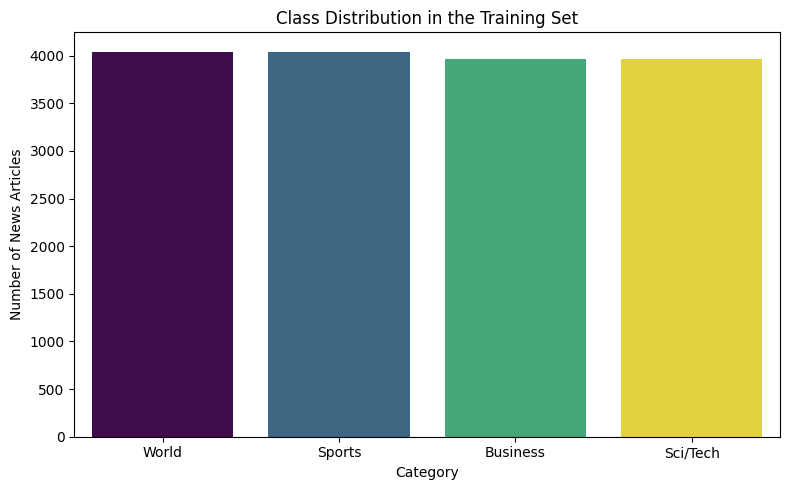

Samples per class:
label
0    4036
1    4042
2    3963
3    3959


In [3]:
# --- EDA: Prepare DataFrame ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the training subset to a Pandas DataFrame for EDA
df_train = pd.DataFrame(dataset_dict['train'])

# --- 1. Class Distribution ---
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='label', hue='label', palette='viridis', legend=False)
plt.title('Class Distribution in the Training Set')
plt.xticks(ticks=[0, 1, 2, 3], labels=class_names)
plt.xlabel('Category')
plt.ylabel('Number of News Articles')
plt.tight_layout()
plt.show()

print('Samples per class:')
print(df_train['label'].value_counts().sort_index().to_string())


### 2.1.2 Sample Texts per Class

Let us look at a few representative examples from each category. This helps us understand the kind of language, domain-specific vocabulary, and sentence structure used in each class.



In [4]:
# --- 2. Sample Texts per Class ---
for label_idx, label_name in enumerate(class_names):
    samples = df_train[df_train['label'] == label_idx]['text'].iloc[:2]
    print(f'\n===== {label_name} =====')
    for i, text in enumerate(samples):
        print(f'  [{i+1}] {text[:200]}...' if len(text) > 200 else f'  [{i+1}] {text}')



===== World =====
  [1] Explosion Rattles Kabul Ahead of Elections (AP) AP - A loud explosion rattled the Afghan capital early Friday, the day before historic elections, and an international peacekeeper said the blast occurr...
  [2] A New Election for Ukrainians Appears Likely Ukraine appears to be headed toward holding a new election under a deal to adopt a reorganization of political power.

===== Sports =====
  [1] Pedro agrees to join the Mets Speaking to a Dominican Republic television station, Martinez said he and the Mets are  quot;happy with everything. quot;. The deal for the pitcher who helped Boston win ...
  [2] EMOTIONAL FAREWELL FOR SAINZ Citroen #39;s Carlos Sainz admitted he was overwhelmed by the support he received on the Rally Catalunya. The Spanish driver, who last month announced his intention to ret...

===== Business =====
  [1] Famous film maker put up for sale Ilford Imaging, the world's largest producer of black and white camera film, is up for sale after go

### 2.1.3 Text Length Distribution (Word Count)

We compute the number of words per article and plot the overall distribution. The `max_length` parameter in tokenization is informed by this analysis — choosing a value that covers most of the data without excessive truncation or padding.



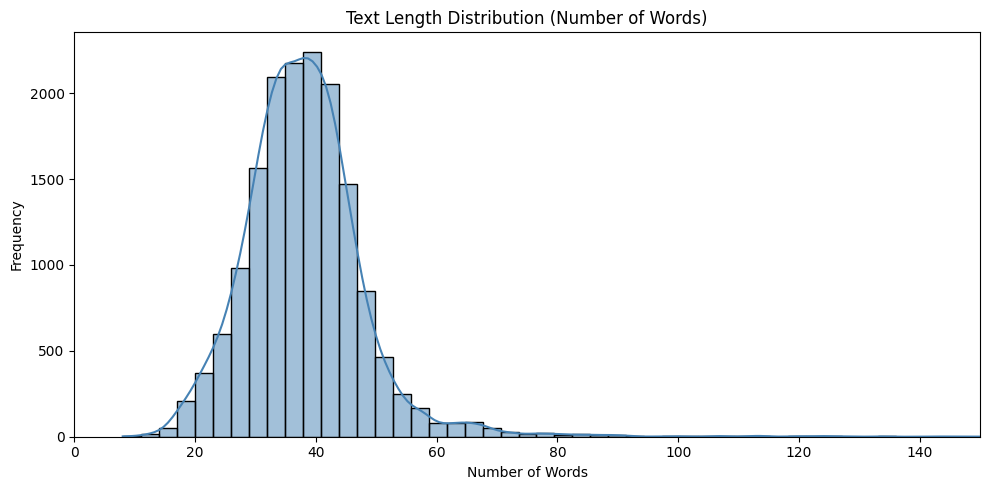

Text length statistics (words):
count    16000.00
mean        37.92
std         10.11
min          8.00
25%         32.00
50%         37.00
75%         43.00
max        157.00
Name: word_count, dtype: float64


In [5]:
# --- 3. Text Length Distribution (Word Count) ---
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df_train['word_count'], bins=50, kde=True, color='steelblue')
plt.title('Text Length Distribution (Number of Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 150)  # Limit to 150 to focus on the bulk of the distribution
plt.tight_layout()
plt.show()

# Descriptive statistics of text length
print('Text length statistics (words):')
print(df_train['word_count'].describe().round(2))


### 2.1.4 Text Length Distribution (Character Count)

In addition to word count, we examine character-level length. This is relevant because transformer tokenizers operate at the sub-word level, and character count gives a rough upper bound on the number of tokens.



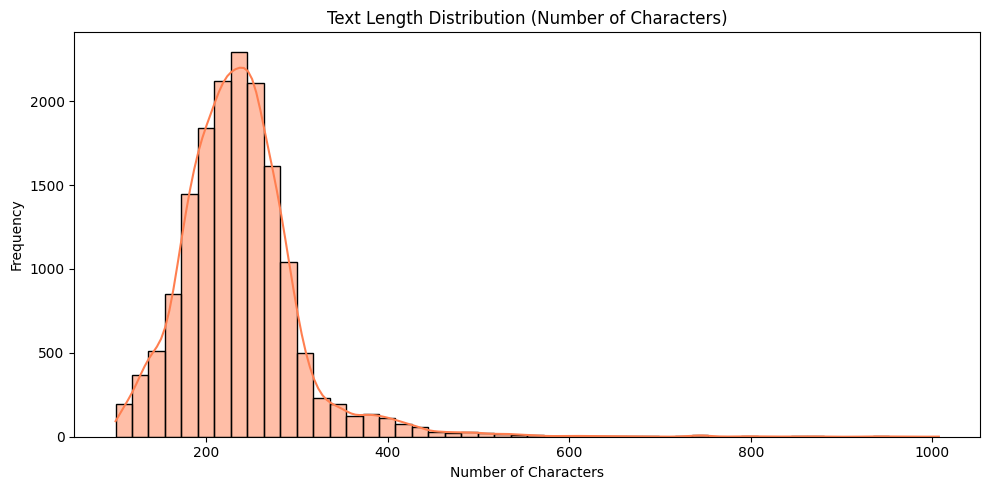

Text length statistics (characters):
count    16000.00
mean       236.80
std         66.14
min        100.00
25%        197.00
50%        232.00
75%        266.00
max       1007.00
Name: char_count, dtype: float64


In [6]:
# --- 4. Text Length Distribution (Character Count) ---
df_train['char_count'] = df_train['text'].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(df_train['char_count'], bins=50, kde=True, color='coral')
plt.title('Text Length Distribution (Number of Characters)')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Text length statistics (characters):')
print(df_train['char_count'].describe().round(2))


### 2.1.5 Per-Class Text Length Distribution

We overlay the kernel density estimate (KDE) of word counts for each class. If one class tends to have significantly longer or shorter texts, the model might learn to exploit length as a shortcut rather than truly understanding the content.



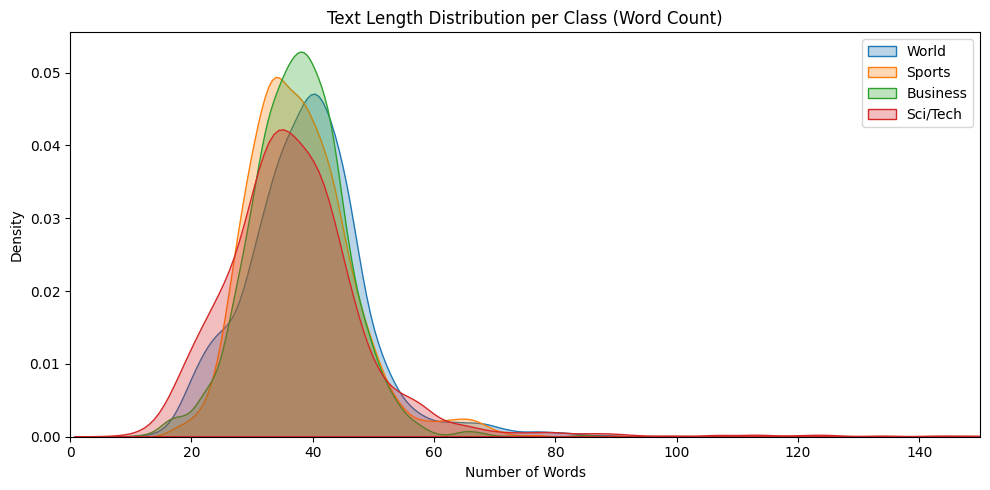

In [7]:
# --- 5. Per-Class Text Length Distribution (KDE) ---
plt.figure(figsize=(10, 5))
for label in range(4):
    subset = df_train[df_train['label'] == label]['word_count']
    sns.kdeplot(subset, label=class_names[label], fill=True, alpha=0.3)
plt.title('Text Length Distribution per Class (Word Count)')
plt.xlabel('Number of Words')
plt.xlim(0, 150)
plt.legend(loc='best')
plt.tight_layout()
plt.show()


### 2.1.6 Average Word Length per Class

Differences in average word length can signal domain-specific vocabulary. For example, *Sci/Tech* articles may contain longer, more technical words compared to *Sports* articles.



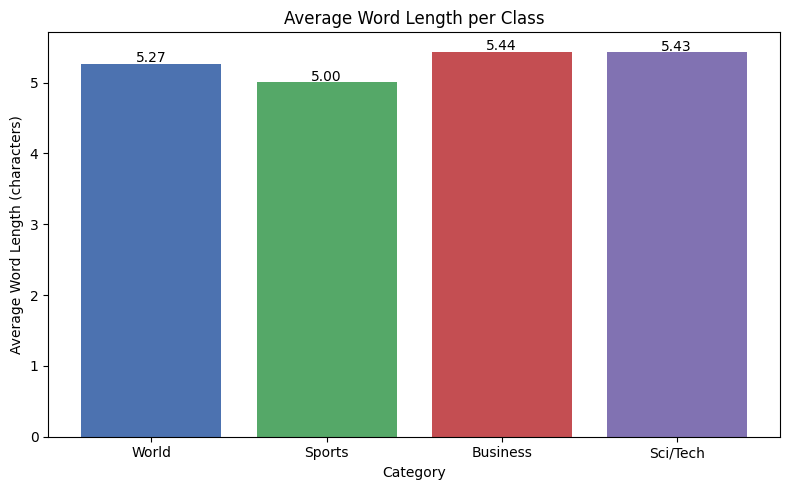

In [ ]:
# --- 6. Average Word Length per Class ---
df_train['avg_word_len'] = df_train['text'].apply(lambda x: np.mean([len(w) for w in x.split()]))

avg_per_class = df_train.groupby('label')['avg_word_len'].mean()
avg_per_class.index = class_names

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_per_class.index, avg_per_class.values, color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'])
plt.title('Average Word Length per Class')
plt.xlabel('Category')
plt.ylabel('Average Word Length (characters)')
for bar, val in zip(bars, avg_per_class.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{val:.2f}', ha='center')
plt.tight_layout()
plt.show()


### 2.1.7 Most Common Words per Class

We display the top 15 most frequent words (after lowercasing and basic stop-word removal) for each category. This reveals the dominant vocabulary and can confirm that the classes are semantically distinct.



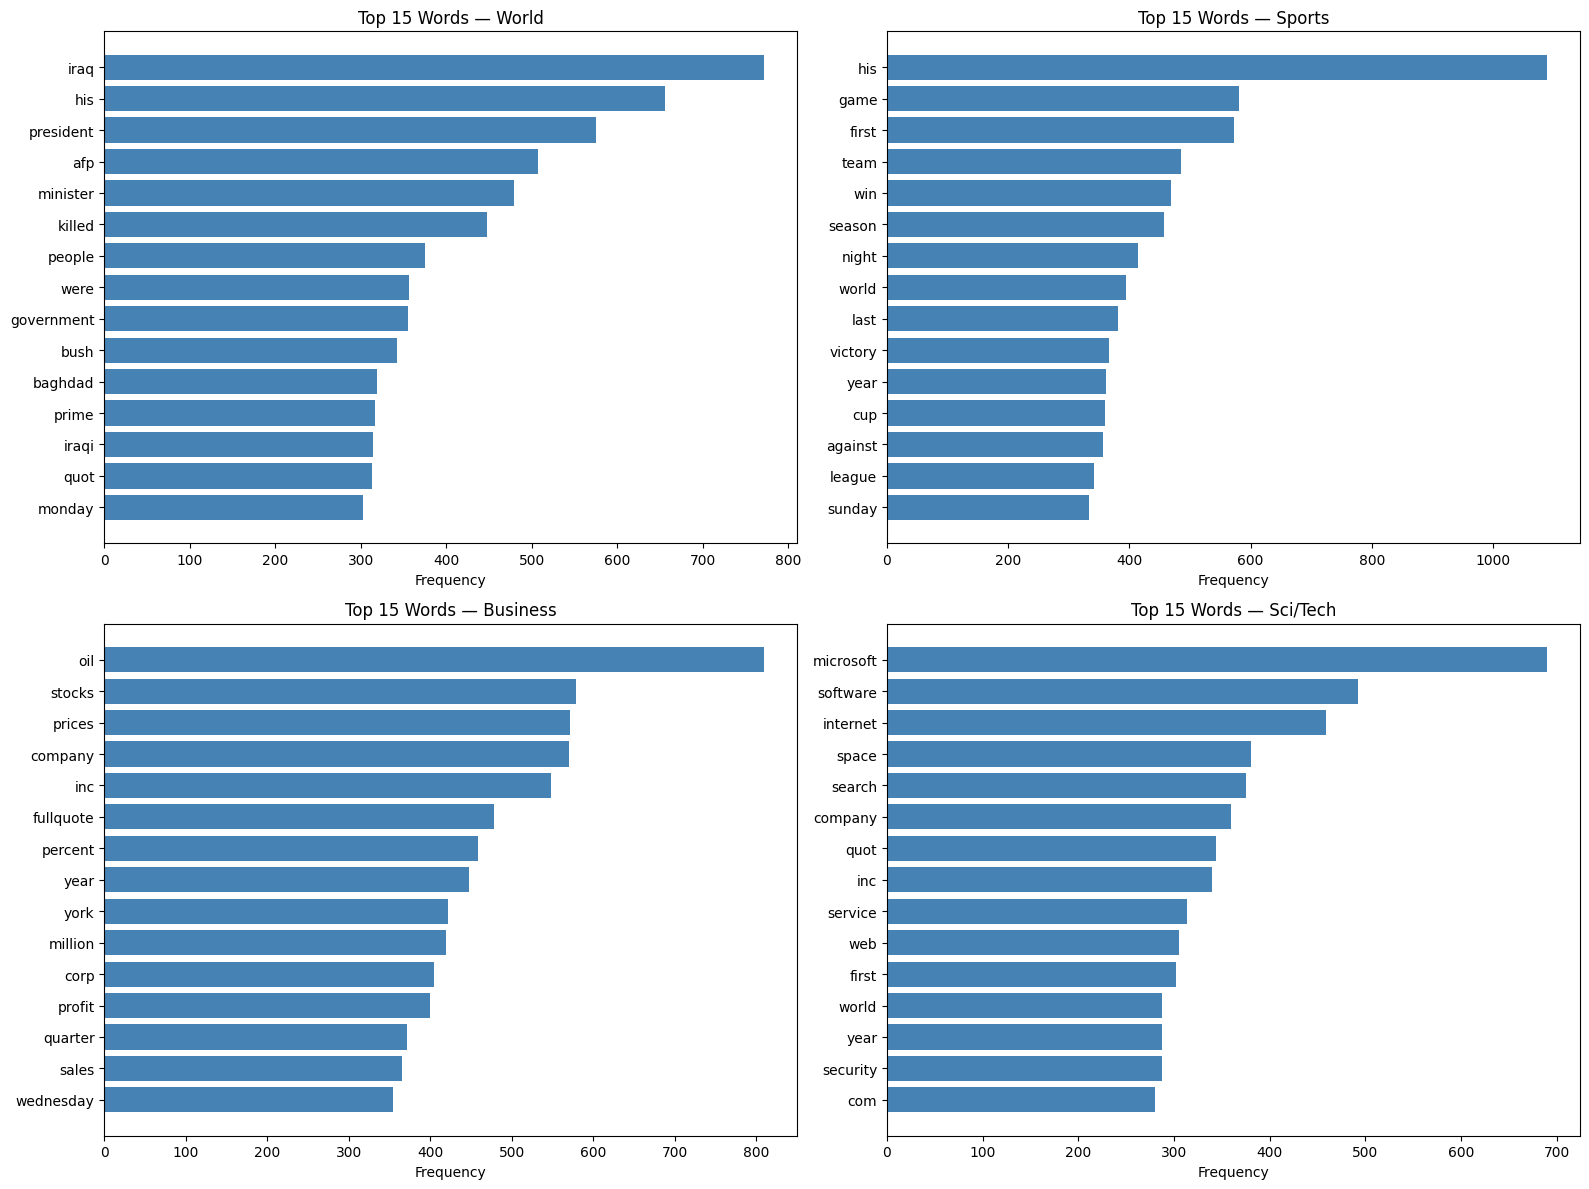

In [ ]:
# --- 7. Most Common Words per Class ---
from collections import Counter
import re

# Basic English stop words list
stop_words = set([
    'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with',
    'by', 'from', 'is', 'it', 'that', 'this', 'was', 'are', 'be', 'has', 'have', 'had',
    'not', 'they', 'we', 'he', 'she', 'its', 'as', 'will', 'would', 'could', 'should',
    'may', 'can', 'do', 'did', 'been', 'being', 'than', 'then', 'so', 'if', 'no', 'up',
    'out', 'about', 'into', 'over', 'after', 'all', 'also', 'new', 'said', 'one', 'two',
    'more', 'just', 'than', 'us', 'our', 'my', 'your', 'their', 'what', 'which', 'who',
    'when', 'how', 'each', 'there', 'where', 'why', 'reuters', 'ap'
])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for label_idx, label_name in enumerate(class_names):
    texts = df_train[df_train['label'] == label_idx]['text']
    words = []
    for t in texts:
        tokens = re.findall(r'\b[a-z]+\b', t.lower())
        words.extend([w for w in tokens if w not in stop_words and len(w) > 2])
    top15 = Counter(words).most_common(15)
    top_words, top_counts = zip(*top15) if top15 else ([], [])

    ax = axes[label_idx]
    ax.barh(range(len(top_words)), top_counts, color='steelblue')
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words)
    ax.invert_yaxis()
    ax.set_title(f'Top 15 Words — {label_name}')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()


### 2.1.8 Vocabulary Size and Unique Word Count

We compare the number of unique words across classes. A larger vocabulary may indicate more diverse topics or more technical language within a category.



In [ ]:
# --- 8. Vocabulary Size per Class ---
for label_idx, label_name in enumerate(class_names):
    texts = df_train[df_train['label'] == label_idx]['text']
    all_words = set()
    for t in texts:
        all_words.update(t.lower().split())
    print(f'{label_name}: {len(all_words):,} unique words')

total_vocab = set()
for t in df_train['text']:
    total_vocab.update(t.lower().split())
print(f'\nTotal vocabulary across all classes: {len(total_vocab):,} unique words')


World: 19,299 unique words
Sports: 20,301 unique words
Business: 18,770 unique words
Sci/Tech: 22,386 unique words

Total vocabulary across all classes: 53,900 unique words


### 2.1.9 Duplicate and Near-Duplicate Check

Duplicate samples in the training set can inflate performance estimates and lead to data leakage if the same text appears in both training and validation splits. We check for exact duplicates.



In [ ]:
# --- 9. Duplicate Check ---
n_total = len(df_train)
n_unique = df_train['text'].nunique()
n_duplicates = n_total - n_unique
print(f'Total training samples: {n_total}')
print(f'Unique texts: {n_unique}')
print(f'Exact duplicates: {n_duplicates} ({100*n_duplicates/n_total:.2f}%)')

if n_duplicates > 0:
    dup_texts = df_train[df_train.duplicated(subset='text', keep=False)]
    print(f'\nExamples of duplicate texts:')
    for text in dup_texts['text'].unique()[:3]:
        print(f'  - "{text[:120]}..."' if len(text) > 120 else f'  - "{text}"')


Total training samples: 16000
Unique texts: 16000
Exact duplicates: 0 (0.00%)
